In [2]:
# Import libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import mannwhitneyu
from scipy.stats import chi2_contingency, fisher_exact

import statsmodels.api as sm

In [3]:
# Load final merged dataset

df = pd.read_csv(
    "datasets/cleaned/final_merged_dataset.csv"
)

df.head()

,FIPS,county,rural_urban,incidence_rate,avg_annual_count,percent_late_stage,median_income_$,total_pop,uninsured_pop,percent_uninsured,poverty_rate
0,6113,Yolo County,Urban,26.0,15.0,51.0,70228.0,215938.0,10466.0,4.846762,17.5
1,6057,Nevada County,Rural,23.6,6.0,45.5,66096.0,NaN,NaN,NaN,12.4
2,6041,Marin County,Urban,23.0,17.0,37.2,115246.0,255421.0,8987.0,3.518505,7.5
3,6111,Ventura County,Urban,21.5,54.0,43.9,88131.0,840257.0,73921.0,8.797427,9.9
4,6007,Butte County,Urban,21.3,12.0,44.3,52537.0,223229.0,13734.0,6.152426,21.4


In [4]:
# Check dataset shape

df.shape

(58, 11)

In [5]:
# Check missing values

df.isna().sum()

FIPS                   0
county                 0
rural_urban            0
incidence_rate        17
avg_annual_count      17
percent_late_stage    17
median_income_$        0
total_pop             21
uninsured_pop         21
percent_uninsured     21
poverty_rate           0
dtype: int64

In [6]:
# Summary statistics

df.describe()

,FIPS,incidence_rate,avg_annual_count,percent_late_stage,median_income_$,total_pop,uninsured_pop,percent_uninsured,poverty_rate
count,58.000000,41.000000,41.000000,41.000000,58.000000,3.700000e+01,37.000000,37.000000,58.000000
mean,6058.000000,19.234146,56.707317,44.085366,67713.603448,1.028809e+06,77477.000000,6.727868,16.294828
std,33.773757,2.487530,101.400011,5.173082,20213.449856,1.729973e+06,163133.312973,1.899300,5.064684
min,6001.000000,12.400000,3.000000,34.700000,40846.000000,8.635200e+04,7413.000000,3.518505,7.500000
25%,6029.500000,17.800000,10.000000,40.400000,53430.500000,2.159380e+05,12202.000000,5.098101,12.400000
50%,6058.000000,19.600000,23.000000,43.900000,62516.000000,4.376690e+05,30689.000000,6.495238,15.900000
75%,6086.500000,20.700000,54.000000,48.000000,80508.500000,9.732660e+05,72076.000000,8.286419,20.300000
max,6115.000000,26.000000,601.000000,60.000000,124055.000000,1.001290e+07,965181.000000,10.025384,27.200000


In [7]:
# Define key variables

group_col = "rural_urban"

incidence_col = "incidence_rate"

late_col = "percent_late_stage"

annual_col = "avg_annual_count"

In [8]:
# Most common area type

print(
    "Most common area:",
    df[group_col].mode()[0]
)

Most common area: Urban


In [ ]:
# Drop missing cancer values for analysis

df_clean = df.dropna(subset=[
    "incidence_rate",
    "percent_late_stage"
])

print("Original rows:", len(df))
print("After dropping missing:", len(df_clean))

Original rows: 58
After dropping missing: 41


In [31]:
# -------------------------------
# T-Test: Urban vs Rural Incidence
# -------------------------------

urban = df[
    df[group_col] == "Urban"
][incidence_col].dropna()

rural = df[
    df[group_col] == "Rural"
][incidence_col].dropna()

print("Urban n:", len(urban))
print("Rural n:", len(rural))

Urban n: 37
Rural n: 4


In [32]:
# Perform independent T-test
t_stat, p_value = stats.ttest_ind(urban, rural)

print(f"T-statistic: {t_stat:.3f}, P-value: {p_value:.3f}")

T-statistic: -0.180, P-value: 0.858


Counties with suppressed counts (“3 or fewer”) were converted to missing values and excluded from analyses. Because suppression occurs primarily in low-population counties, findings may not generalize to small or rural counties.

In [33]:
#Mann-Whitney U Test

u_stat, p_val = mannwhitneyu(urban, rural, alternative="two-sided")

print("Mann-Whitney U test")
print(f"U-statistic = {u_stat}")
print(f"P-value     = {p_val:.4f}")

Mann-Whitney U test
U-statistic = 75.5
P-value     = 0.9649


In [36]:
from scipy.stats import ttest_ind
# --- Hypothesis Test : Does Rural Status Increase Cancer Incidence? ---

# Welch's t-test
t_stat, p_val = ttest_ind(urban, rural, equal_var=False)

print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {p_val:.4f}")

T-statistic: -0.134
P-value: 0.9014


In [34]:
# -------------------------------
# Chi-Square + Fisher's Exact Test
# -------------------------------

# Drop missing only for these variables
df_test = df_clean.dropna(subset=[group_col, late_col]).copy()

# Create binary variable: High Late Stage (above median)
median_late = df_test[late_col].median()
df_test["high_late_stage"] = (df_test[late_col] > median_late).astype(int)

# Create contingency table
cont_table = pd.crosstab(df_test[group_col], df_test["high_late_stage"])

print("Contingency Table (Rural/Urban × High Late Stage)")
print(cont_table)

# --- Chi-Square Test ---
chi2, p_chi, dof, expected = chi2_contingency(cont_table)

print("\nChi-Square Test Results")
print(f"Chi-square statistic: {chi2:.3f}")
print(f"P-value: {p_chi:.4f}")
print("Expected Frequencies:")
print(expected)

# --- Fisher's Exact Test ---
odds_ratio, p_fisher = fisher_exact(cont_table)

print("\nFisher’s Exact Test Results")
print(f"Odds ratio: {odds_ratio:.3f}")
print(f"P-value: {p_fisher:.4f}")

Contingency Table (Rural/Urban × High Late Stage)
high_late_stage   0   1
rural_urban            
Rural             0   4
Urban            21  16

Chi-Square Test Results
Chi-square statistic: 2.660
P-value: 0.1029
Expected Frequencies:
[[ 2.04878049  1.95121951]
 [18.95121951 18.04878049]]

Fisher’s Exact Test Results
Odds ratio: 0.000
P-value: 0.0478


Fisher’s Exact Test indicated a statistically significant association between rural status and high late-stage breast cancer percentage (p = 0.048). All four rural counties with available data were classified as high late-stage. However, because the rural sample size is very small (n = 4), this result should be interpreted with caution.

In [37]:
# -------------------------------
# Probability Calculations
# -------------------------------

median_inc = df[incidence_col].median()

high_incidence = (
    df[incidence_col] > median_inc
)

print(
    "Probability of high incidence:",
    round(high_incidence.mean(), 2)
)

Probability of high incidence: 0.34


In [38]:
# Probability of Rural AND High Late Stage

df_prob = df.dropna(
    subset=[group_col, late_col]
).copy()

df_prob[group_col] = (
    df_prob[group_col]
    .str.strip()
    .str.lower()
)

median_late = df_prob[late_col].median()

df_prob["high_late"] = (
    df_prob[late_col] > median_late
)

both = (
    (df_prob[group_col] == "rural")
    &
    (df_prob["high_late"])
)

print(
    "Probability Rural AND High Late-Stage:",
    round(both.mean(), 2)
)

Probability Rural AND High Late-Stage: 0.1


In [39]:
# -------------------------------
# Correlation Matrix
# -------------------------------

numeric_vars = [
    "incidence_rate",
    "percent_late_stage",
    "avg_annual_count",
    "median_income_$",
    "percent_uninsured",
    "poverty_rate"
]

corr_matrix = df[numeric_vars].corr()

corr_matrix

,incidence_rate,percent_late_stage,avg_annual_count,median_income_$,percent_uninsured,poverty_rate
incidence_rate,1.000000,0.019701,0.028268,0.305165,-0.418748,-0.384938
percent_late_stage,0.019701,1.000000,-0.065784,-0.614218,0.428544,0.633942
avg_annual_count,0.028268,-0.065784,1.000000,0.145018,0.228426,-0.113524
median_income_$,0.305165,-0.614218,0.145018,1.000000,-0.658058,-0.769198
percent_uninsured,-0.418748,0.428544,0.228426,-0.658058,1.000000,0.584926
poverty_rate,-0.384938,0.633942,-0.113524,-0.769198,0.584926,1.000000


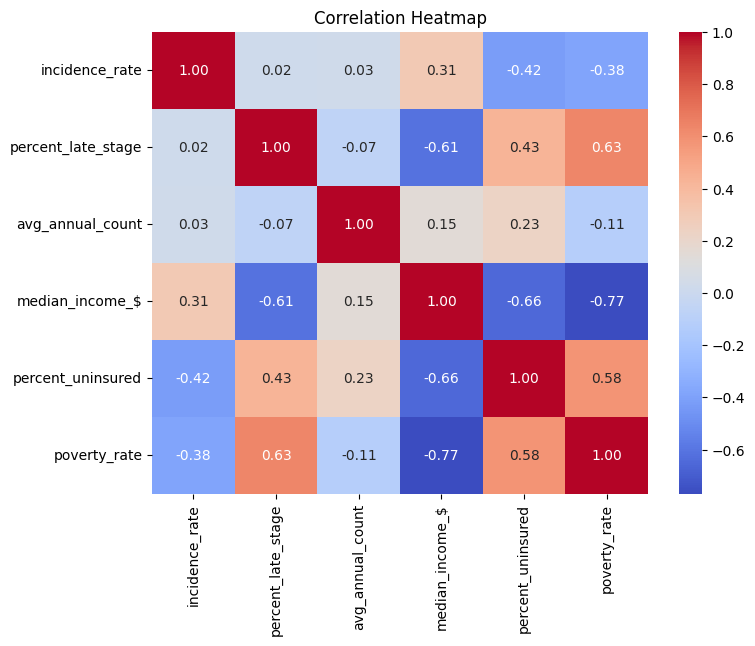

In [40]:
# Correlation Heatmap

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [41]:
# -------------------------------
# Linear Regression
# -------------------------------

model_df = df[[
    "percent_late_stage",
    "median_income_$",
    "percent_uninsured",
    "poverty_rate"
]].dropna()

# Outcome variable
y = model_df["percent_late_stage"]

# Predictor variables
X = model_df[[
    "median_income_$",
    "percent_uninsured",
    "poverty_rate"
]]

# Add intercept
X = sm.add_constant(X)

# Train model
model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:     percent_late_stage   R-squared:                       0.464
Model:                            OLS   Adj. R-squared:                  0.415
Method:                 Least Squares   F-statistic:                     9.520
Date:                Thu, 07 May 2026   Prob (F-statistic):           0.000112
Time:                        22:19:07   Log-Likelihood:                -102.25
No. Observations:                  37   AIC:                             212.5
Df Residuals:                      33   BIC:                             218.9
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                36.4611     10.32

**Linear Regression Interpretation**

The overall regression model is statistically significant (F-test p = 0.0001) and explains about 46% of the variation in late-stage cancer rates (R² = 0.464).

*Key Results:*

Median Income ($)

- p = 0.731 (not significant)

- There is no strong evidence that county median income is related to late-stage cancer rates in this model.

Percent Uninsured

- p = 0.878 (not significant)
- The percentage of uninsured individuals does not show a significant relationship with late-stage cancer rates.

Poverty Rate

- p = 0.041 (significant)
- Counties with higher poverty rates tend to have higher percentages of late-stage cancer diagnoses.


Conclusion: Among the socioeconomic variables tested, poverty rate appears to have the strongest relationship with late-stage cancer rates among women under 50 across counties, while median income and insurance rates were not statistically significant in this model.

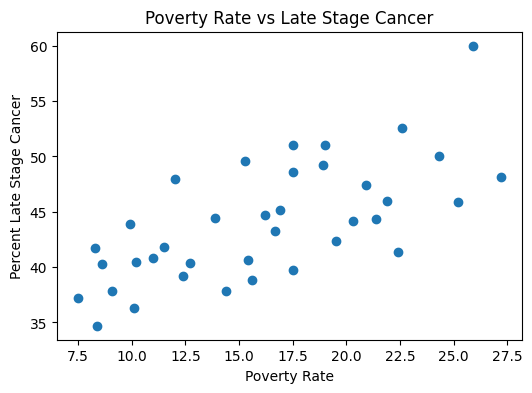

In [22]:
# Scatter Plot

plt.figure(figsize=(6, 4))

plt.scatter(
    model_df["poverty_rate"],
    y
)

plt.xlabel("Poverty Rate")

plt.ylabel("Percent Late Stage Cancer")

plt.title(
    "Poverty Rate vs Late Stage Cancer"
)

plt.show()